In [100]:
import onep
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import scipy.stats

In [101]:
#Multiple mice
import pickle

In [126]:
# Load the pickle file
with open('/Users/suthardr/Desktop/collection_cxtb_fc.pkl', 'rb') as file:
    collection_cxta_fc = pickle.load(file)

with open('/Users/suthardr/Desktop/collection_cxtb_recall.pkl', 'rb') as file:
    collection_cxta_recall = pickle.load(file)

In [151]:

animal = 'astro9'

In [152]:
# Assuming load_registration_table() returns a list of lists

load_reg_table = collection_cxta_fc.animals[animal].load_registration_table()

# Ensure accepted_indices is a list of valid row indices
rejected_indices = collection_cxta_fc.animals[animal].rejected_inds

# Convert rejected_indices to a pandas Series for easier manipulation
rejected_indices_series = pd.Series(rejected_indices)

# Filter load_reg_table based on rejected_indices in column 0
filtered_reg_table = load_reg_table[~load_reg_table[0].isin(rejected_indices_series)]

print(filtered_reg_table)

/Users/suthardr/Desktop/Cell_Traces/CellReg/astro9_FOV1/astro9_cell_reg.csv
     0   1
0    0  -1
1    1  -1
2    2  -1
3    3  -1
4    4  -1
..  ..  ..
185 -1  75
186 -1  76
187 -1  77
188 -1  78
189 -1  79

[187 rows x 2 columns]


In [153]:
# Ensure accepted_indices is a list of valid row indices
rejected_indices_recall = collection_cxta_recall.animals[animal].rejected_inds

# Convert rejected_indices to a pandas Series for easier manipulation
rejected_indices_series_recall = pd.Series(rejected_indices_recall)

# Filter load_reg_table based on rejected_indices in column 0
filtered_reg_table_recall = filtered_reg_table[~filtered_reg_table[1].isin(rejected_indices_series_recall)]

print(filtered_reg_table_recall)

     0   1
0    0  -1
1    1  -1
2    2  -1
3    3  -1
4    4  -1
..  ..  ..
185 -1  75
186 -1  76
187 -1  77
188 -1  78
189 -1  79

[186 rows x 2 columns]


In [154]:
#Filter by cells only in both days
both_idxs = filtered_reg_table_recall.loc[(filtered_reg_table_recall[0] != -1) & (filtered_reg_table_recall[1] != -1)]
both_idxs

,0,1
24,24,5
26,26,29
38,38,9
47,47,20
58,58,58
74,74,10


In [155]:
fc_traces = collection_cxta_fc.animals[animal].get_traces()
recall_traces = collection_cxta_recall.animals[animal].get_traces()

In [156]:
fc_active = fc_traces[both_idxs[0]]
fc_active

array([[-0.00036864, -0.00787927, -0.00304559, ..., -0.00070377,
         0.00123832, -0.00352497],
       [-0.00097942,  0.00295194, -0.00155795, ..., -0.00356344,
        -0.00323586, -0.00078162],
       [ 0.00286598,  0.00433902, -0.00200361, ...,  0.00041963,
        -0.00488633,  0.00528635],
       [-0.00396538, -0.0001503 , -0.00015082, ..., -0.00372927,
         0.00550393,  0.00104456],
       [-0.00477107, -0.00413356, -0.00833448, ..., -0.00196339,
         0.00414645, -0.00571847],
       [ 0.00121708, -0.00197074, -0.00553788, ...,  0.00210244,
        -0.00707204, -0.008598  ]])

In [157]:
recall_active = recall_traces[both_idxs[1]]
recall_active

array([[ 0.00526641,  0.00796767,  0.00271103, ...,  0.0013192 ,
        -0.00567341, -0.01849394],
       [ 0.0077929 , -0.00021136, -0.00277348, ...,  0.00341316,
         0.0028909 ,  0.00213484],
       [-0.00328677,  0.00228768, -0.00305239, ..., -0.00908592,
        -0.01386142, -0.00592009],
       [ 0.00871803,  0.00050127,  0.00536598, ..., -0.0003817 ,
        -0.00231159, -0.00386243],
       [-0.00996938, -0.00606177, -0.00645857, ..., -0.00068089,
        -0.00649953, -0.01318604],
       [-0.0138329 , -0.01457288, -0.00706833, ..., -0.00095374,
        -0.00214752, -0.00141574]])

In [158]:
fc_dfz = stats.zscore(fc_active, axis=1)
recall_dfz = stats.zscore(recall_active, axis=1)

In [159]:
fc_dfz = fc_dfz[:, :3303]
recall_dfz = recall_dfz[:, :3303]

In [160]:
across_eta_, time = onep.eta_individual_cells(
    data=fc_dfz,
    timestamps=collection_cxta_fc.animals[animal].Timestamps[:3303, ].to_numpy().squeeze(),
    events=[[120, 180, 240, 300], ],  #detected onsets
    window=28
)

In [161]:
across_eta_R, time_R = onep.eta_individual_cells(
    data=recall_dfz,
    timestamps=collection_cxta_recall.animals[animal].Timestamps[:3303, ].to_numpy().squeeze(),
    events=[[67.54823800666061, 111.5145467683924, 143.0903503336361], ],  #detected onsets
    window=28
)

#astro3 - 71.9448772796669, 224.9276649396253, 266.7955865787648

#astro4-121.5068386007773, 171.4685321043864, 243.9129876846197,
       #285.4811166796225

#astro5 - 34.67342136063298, 89.83114064325375, 173.8667238256524

#astro6 - 84.73501601221373,  148.286278021374, 174.9658172610687,
       #266.6954690290077

#astro7 - 43.16693610899183,  118.509227373297, 229.5241950054496,
       #266.8955702479564

#astro8 - 91.42997888754353,133.3978380490389,248.8094507431512,  275.489018352959

#astro9 - 67.54823800666061, 111.5145467683924, 143.0903503336361

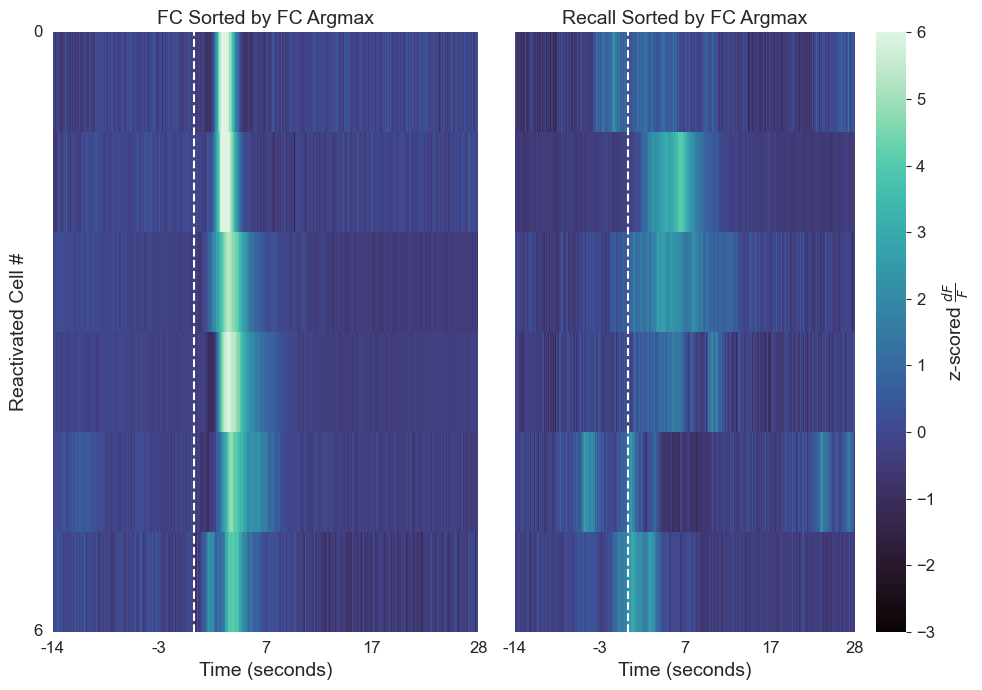

In [162]:
#Argmax sort - recall on FC
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

max_idxs = np.zeros(6)  #change based on # of overlapping cells
for i in range(across_eta_.shape[0]):
    idx = np.argmax(across_eta_[i])
    max_idxs[i] = idx
new_table = np.hstack((both_idxs, max_idxs.reshape(-1, 1)))
fc_idxs = np.argsort(new_table[:, 2])
###################
sorted_arr_fc = across_eta_[fc_idxs] #across_eta (FC) traces at shock sorted by fc_argmax
sorted_arr_recall = across_eta_R[fc_idxs] #plot just the eta times

# Extract first and last index for y-axis ticks
first_last_fc = [0, sorted_arr_fc.shape[0]]
first_last_recall = [0, sorted_arr_recall.shape[0]]

# Set up FacetGrid for plotting
fig, axs = plt.subplots(1, 2, figsize=(10, 7),sharey= True)  # Adjust figsize as needed

# Plot the FC sorted heatmap
sns.heatmap(sorted_arr_fc, cmap='mako', cbar=False, ax=axs[0], vmin=-3, vmax=6, rasterized=True, annot=False)
axs[0].axvline((time.shape[0] / 3), linestyle='--', color='white')
axs[0].tick_params(axis='both', which='major', labelsize=12)
axs[0].set_xticks(np.linspace(0, sorted_arr_fc.shape[1], 5))
axs[0].set_xticklabels(np.linspace(np.min(time), np.max(time), 5).astype(int), rotation=0)
axs[0].set_yticks(first_last_fc)  # Set y-ticks to first and last indices
axs[0].set_yticklabels([first_last_fc[0], first_last_fc[1]], rotation=0)  # Label y-ticks
axs[0].set_title('FC Sorted by FC Argmax', fontsize=14)
axs[0].set_xlabel('Time (seconds)', fontsize=14)
axs[0].set_ylabel('Reactivated Cell #', fontsize=14)

# Plot the Recall sorted heatmap
heatmap = sns.heatmap(sorted_arr_recall, cmap='mako', cbar=True, rasterized=True, cbar_kws={"label": r"z-scored $\frac{dF}{F}$"}, ax=axs[1], vmin=-3, vmax=6, annot=False)
axs[1].axvline((time_R.shape[0] / 3), linestyle='--', color='white')
axs[1].tick_params(axis='both', which='major', labelsize=12)
axs[1].set_xticks(np.linspace(0, sorted_arr_recall.shape[1], 5))
axs[1].set_xticklabels(np.linspace(np.min(time_R), np.max(time_R), 5).astype(int), rotation=0)
axs[1].set_yticks(first_last_recall)  # Set y-ticks to first and last indices
axs[1].set_yticklabels([first_last_recall[0], first_last_recall[1]], rotation=0)  # Label y-ticks
axs[1].set_title('Recall Sorted by FC Argmax', fontsize=14)
axs[1].set_xlabel('Time (seconds)', fontsize=14)

# Get the current colorbar object from the heatmap
cbar = heatmap.collections[0].colorbar
#
# # Set font size for colorbar labels
cbar.ax.yaxis.set_tick_params(labelsize=12)
cbar.set_label(r"z-scored $\frac{dF}{F}$", fontsize=14)

# Adjust layout and display the plot
plt.tight_layout()
plt.savefig('/Users/suthardr/Desktop/Rui_Newest_Model_July/Recall_sorted_FC_argmax/astro9_reactivated_sort_sequence_correct.svg')

In [62]:
max_idxs_fc = np.zeros(sorted_arr_fc.shape[0], dtype=int)

# # Iterate over each row of across_eta_ to find the maximum index
for i in range(sorted_arr_fc.shape[0]):
    idx = np.argmax(sorted_arr_fc[i])
    max_idxs_fc[i] = idx

# Now, use max_idxs to index into the time array
argmax_fc = time[max_idxs_fc]
argmax_fc

array([ 1.6372315 ,  2.13842482,  2.23866348,  2.23866348,  2.23866348,
        2.23866348,  2.43914081,  2.43914081,  2.43914081,  2.53937947,
        2.53937947,  2.63961814,  2.63961814,  2.63961814,  2.63961814,
        2.7398568 ,  2.7398568 ,  2.7398568 ,  2.84009547,  2.84009547,
        2.84009547,  2.84009547,  2.84009547,  2.94033413,  2.94033413,
        3.04057279,  3.04057279,  3.04057279,  3.14081146,  3.14081146,
        3.34128878,  3.34128878,  3.34128878,  3.34128878,  3.44152745,
        3.54176611,  3.54176611,  3.54176611,  3.54176611,  3.64200477,
        3.64200477,  3.64200477,  3.64200477,  3.64200477,  3.64200477,
        3.64200477,  3.64200477,  3.74224344,  3.74224344,  3.74224344,
        3.74224344,  3.74224344,  3.74224344,  3.8424821 ,  3.8424821 ,
        3.8424821 ,  3.8424821 ,  4.04295943,  4.04295943,  4.04295943,
        4.14319809,  4.14319809,  4.24343675,  4.24343675,  4.34367542,
        4.34367542,  4.34367542,  4.44391408,  4.44391408,  4.64

In [63]:
max_idxs_recall = np.zeros(sorted_arr_recall.shape[0], dtype=int)

# Iterate over each row of across_eta_ to find the maximum index
for i in range(sorted_arr_recall.shape[0]):
    idx = np.argmax(sorted_arr_recall[i])
    max_idxs_recall[i] = idx

argmax_recall = time_R[max_idxs_recall]
argmax_recall

array([ 6.24821002,  3.94272076,  2.43914081,  0.13365155,  5.74701671,
        0.13365155,  1.13603819,  0.03341289,  4.74463007,  0.13365155,
        6.34844869, 10.25775656,  5.54653938,  1.13603819,  6.74940334,
        3.04057279,  1.03579952,  3.8424821 ,  4.14319809,  3.8424821 ,
        3.24105012, 13.1646778 ,  1.83770883,  0.8353222 ,  3.34128878,
        7.9522673 ,  2.43914081,  1.13603819,  4.84486874,  3.64200477,
        4.14319809,  2.33890215,  3.8424821 , 15.57040573,  0.73508353,
        0.43436754,  6.24821002,  1.03579952, 18.97852029, 10.45823389,
       10.85918854,  4.9451074 ,  9.75656325, 13.56563246,  8.25298329,
        3.14081146,  1.53699284,  7.150358  , 11.46062053,  2.33890215,
       11.05966587,  1.43675418,  4.04295943,  1.03579952,  5.54653938,
        8.45346062,  6.14797136,  8.05250597,  6.24821002, 10.1575179 ,
        7.45107399,  6.44868735,  4.74463007,  4.9451074 ,  4.24343675,
       11.46062053, 11.05966587, 12.26252983, 28.        ,  6.54

In [64]:
# #Run spearman's correlation on x and y
rho, p = stats.spearmanr(argmax_fc,argmax_recall, axis=0)

#print Spearman rank correlation and p-value
print(rho)
print(p)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
0.3499783466198291
0.0005077365532936449


In [65]:
import pandas as pd
import numpy as np

# Create a DataFrame from the arrays
df = pd.DataFrame({
    'FC': argmax_fc,
    'Recall': argmax_recall
})

print(df)


           FC     Recall
0    1.637232   6.248210
1    2.138425   3.942721
2    2.238663   2.439141
3    2.238663   0.133652
4    2.238663   5.747017
..        ...        ...
90   8.353222   0.534606
91   8.754177   2.639618
92  10.658711  12.563246
93  14.267303   3.842482
94  15.169451   0.133652

[95 rows x 2 columns]


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Text(0, 0.5, 'Recall sorted FC Argmax: Time (s)')

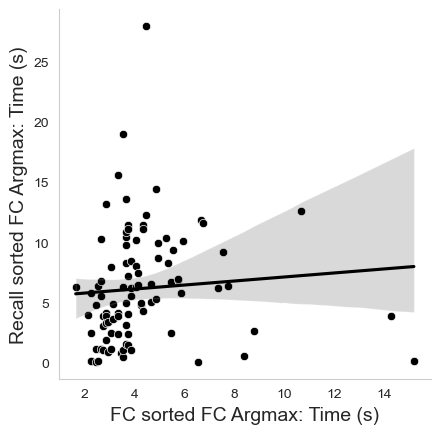

In [66]:
import pandas as pd
import statsmodels.api as sm

animal = ['astro3']

# create a datatable that has the animal, the slope, the intercept, and the p-values
df_results = pd.DataFrame(columns=['animal', 'slope', 'intercept', 'p_value_slope', 'p_value_bias', 'r_squared'])

# run regression on the data
y = df['Recall']
X = df['FC']

# add constant
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
# append the animal name, slope, intercept, and p-value to the results dataframe
df_results = pd.concat((df_results, pd.DataFrame({'animal': animal, 'slope': model.params['FC'],
                                                  'intercept': model.params['const'],
                                                  'p_value_slope': model.pvalues['FC'],
                                                  "p_value_bias": model.pvalues["const"], "r_squared": model.rsquared},
                                                 index=[0])),
                       ignore_index=True)
# generate a plot and save for each animal
# Plot the scatter plot and the regression line
fig, ax = plt.subplots(figsize=(4.8, 4.8))

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
##75bfaa
sns.scatterplot(data=df, x='FC', y='Recall', c='black', ax=ax)
sns.regplot(data=df, x='FC', y='Recall', color='black', ax=ax, scatter=False,
            ci=95)
# Set axis limits and labels
# ax.set_xlim(x_min, x_max)
# ax.set_ylim(y_min, y_max)
ax.set_xlabel('FC sorted FC Argmax: Time (s)', fontsize=14)
ax.set_ylabel('Recall sorted FC Argmax: Time (s)', fontsize=14)

# save fig
# fig.savefig(
#     '/Users/suthardr/Desktop/Rui_Newest_Model_July/Recall_argmax_crossvalled/Recall_crossvalled_scatter_astro6_unadjusted.svg')

In [67]:

df_results

,animal,slope,intercept,p_value_slope,p_value_bias,r_squared
0,astro3,0.167598,5.429707,0.447453,0.000002,0.006219
